## Dataset Loading

The Financial Inclusion in Africa dataset contains demographic and socioeconomic information from four East African countries: Kenya, Rwanda, Tanzania, and Uganda. The objective is to predict whether an individual has a bank account based on their characteristics.

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [66]:
df = pd.read_csv("C:\\ML_project\\Train .csv")

# Data Exploration

In [67]:
df.head()

,country,year,uniqueid,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_1,Yes,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,uniqueid_2,No,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,uniqueid_3,Yes,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed
3,Kenya,2018,uniqueid_4,No,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private
4,Kenya,2018,uniqueid_5,No,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23524 entries, 0 to 23523
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   country                 23524 non-null  object
 1   year                    23524 non-null  int64 
 2   uniqueid                23524 non-null  object
 3   bank_account            23524 non-null  object
 4   location_type           23524 non-null  object
 5   cellphone_access        23524 non-null  object
 6   household_size          23524 non-null  int64 
 7   age_of_respondent       23524 non-null  int64 
 8   gender_of_respondent    23524 non-null  object
 9   relationship_with_head  23524 non-null  object
 10  marital_status          23524 non-null  object
 11  education_level         23524 non-null  object
 12  job_type                23524 non-null  object
dtypes: int64(3), object(10)
memory usage: 2.3+ MB


In [69]:
df1=df.copy()
df1 = df1.drop(columns=['uniqueid'])

Dataset Summary
- Observations: 23,524
- Variables: 13
- Target Variable: bank_account
- Predictors: 11 (after dropping uniqueid)
- Missing Values: None

In [70]:
print(df1["bank_account"].value_counts(normalize=True)*100)

bank_account
No     85.920762
Yes    14.079238
Name: proportion, dtype: float64


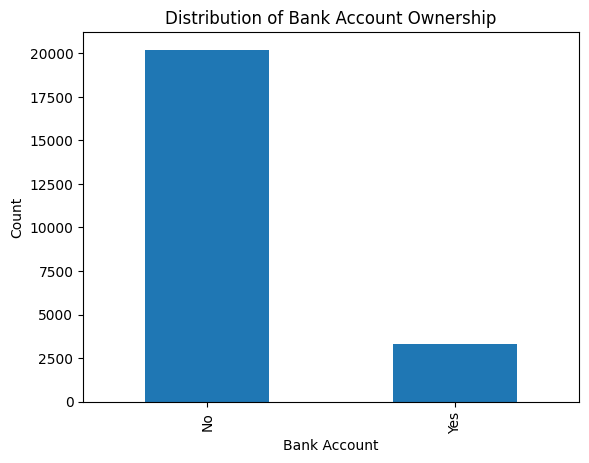

In [71]:

df1["bank_account"].value_counts().plot(kind="bar")
plt.title("Distribution of Bank Account Ownership")
plt.xlabel("Bank Account")
plt.ylabel("Count")
plt.show()

In [72]:
print(df1["country"].value_counts(normalize=True)*100)

country
Rwanda      37.132290
Tanzania    28.141473
Kenya       25.794933
Uganda       8.931304
Name: proportion, dtype: float64


In [73]:
print(df1["education_level"].value_counts(normalize=True)*100)

education_level
Primary education                  54.374256
No formal education                19.193164
Secondary education                17.951879
Tertiary education                  4.918381
Vocational/Specialised training     3.413535
Other/Dont know/RTA                 0.148784
Name: proportion, dtype: float64


In [74]:
print(df1["job_type"].value_counts(normalize=True)*100)

job_type
Self employed                   27.363544
Informally employed             23.792722
Farming and Fishing             23.129570
Remittance Dependent            10.742221
Other Income                     4.591056
Formally employed Private        4.484781
No Income                        2.665363
Formally employed Government     1.645128
Government Dependent             1.049991
Dont Know/Refuse to answer       0.535623
Name: proportion, dtype: float64


In [75]:
print(df1["cellphone_access"].value_counts(normalize=True)*100)

cellphone_access
Yes    74.196565
No     25.803435
Name: proportion, dtype: float64


In [76]:
print(df1["location_type"].value_counts(normalize=True)*100)

location_type
Rural    60.971774
Urban    39.028226
Name: proportion, dtype: float64


In [77]:
print(df1["gender_of_respondent"].value_counts(normalize=True)*100)

gender_of_respondent
Female    58.990818
Male      41.009182
Name: proportion, dtype: float64


In [78]:
print(df1["household_size"].describe())

count    23524.000000
mean         3.797483
std          2.227613
min          1.000000
25%          2.000000
50%          3.000000
75%          5.000000
max         21.000000
Name: household_size, dtype: float64


In [79]:
print(df1["age_of_respondent"].describe())

count    23524.000000
mean        38.805220
std         16.520569
min         16.000000
25%         26.000000
50%         35.000000
75%         49.000000
max        100.000000
Name: age_of_respondent, dtype: float64




The target variable, bank_account, is imbalanced, with approximately 86% of respondents not having a bank account and 14% having one. Therefore, accuracy alone may not fully represent model performance, and additional metrics such as precision, recall, and F1-score will be considered.

In [80]:
# separating features and target variable
X = df1.drop("bank_account", axis=1)

y = df1["bank_account"]

In [81]:
encoder = LabelEncoder()

y = encoder.fit_transform(y)

# Check
np.unique(y, return_counts=True)

(array([0, 1]), array([20212,  3312]))

In [82]:
numerical_features = X.select_dtypes(include=["int64"]).columns

categorical_features = X.select_dtypes(include=["object"]).columns


print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
Index(['year', 'household_size', 'age_of_respondent'], dtype='object')

Categorical features:
Index(['country', 'location_type', 'cellphone_access', 'gender_of_respondent',
       'relationship_with_head', 'marital_status', 'education_level',
       'job_type'],
      dtype='object')


In [83]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer


# Numerical preprocessing
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])


# Combine both
preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

Numerical variables were standardized using StandardScaler to improve the performance of distance-based algorithms such as KNN and SVM. Categorical variables were transformed using one-hot encoding because the categories do not possess an inherent numerical order

In [84]:
X_processed = preprocessor.fit_transform(X)

print(X_processed.shape)

(23524, 40)


In [85]:
from sklearn.model_selection import StratifiedKFold, cross_validate

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

In [86]:
cv = StratifiedKFold(
    n_splits=2,
    shuffle=True,
    random_state=42
)

In [87]:
models = {

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ),

    "SVM": SVC(
        kernel="rbf",
        class_weight="balanced",
        random_state=42
    ),

    "ANN": MLPClassifier(
        hidden_layer_sizes=(100,50),
        max_iter=1000,
        learning_rate_init=0.001,
        early_stopping=True,
        random_state=42
    )
}

In [88]:
scoring = {
    "Accuracy": "accuracy",
    "Precision": "precision",
    "Recall": "recall",
    "F1": "f1"
}

In [89]:
from sklearn.pipeline import Pipeline

results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=scoring
    )

    results.append({
        "Model": name,
        "Accuracy": scores["test_Accuracy"].mean(),
        "Precision": scores["test_Precision"].mean(),
        "Recall": scores["test_Recall"].mean(),
        "F1 Score": scores["test_F1"].mean()
    })


In [93]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,KNN,0.877232,0.613908,0.346316,0.442754
1,Decision Tree,0.816358,0.363022,0.402476,0.381712
2,SVM,0.792170,0.380305,0.756039,0.506021
3,ANN,0.886244,0.683647,0.357488,0.469472


In [96]:
print(results_df.sort_values(
    by="F1 Score",
    ascending=False
))

           Model  Accuracy  Precision    Recall  F1 Score
2            SVM  0.792170   0.380305  0.756039  0.506021
3            ANN  0.886244   0.683647  0.357488  0.469472
0            KNN  0.877232   0.613908  0.346316  0.442754
1  Decision Tree  0.816358   0.363022  0.402476  0.381712


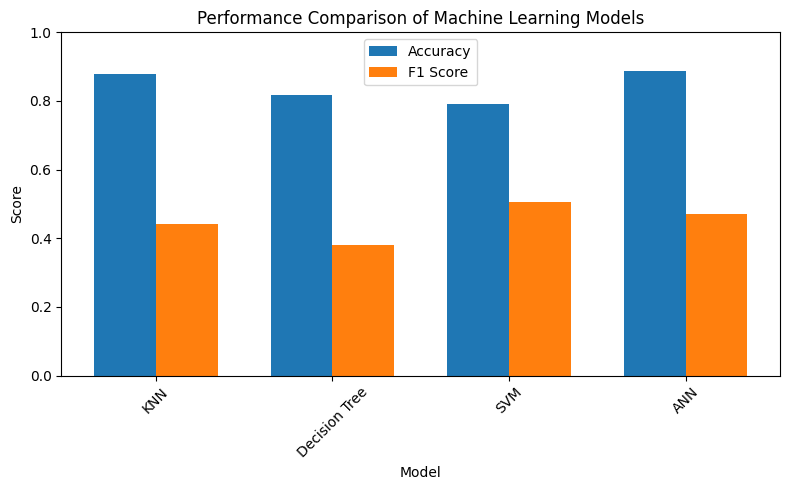

In [98]:

models = results_df["Model"]
accuracy = results_df["Accuracy"]
f1 = results_df["F1 Score"]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(
    x - width/2,
    accuracy,
    width,
    label="Accuracy"
)

plt.bar(
    x + width/2,
    f1,
    width,
    label="F1 Score"
)

plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Performance Comparison of Machine Learning Models")
plt.xticks(x, models, rotation=45)
plt.ylim(0,1)

plt.legend()
plt.tight_layout()

plt.show()